In [2]:
import sys
sys.path.insert(0, '../src')
from models import load_model_only
from utils import *

config = parse_config('../configs/tversky_sirl.yaml')
model = load_model_only(config, "../results/tversky_sirl_gridrobot/tversky_sirl_dim10_fbank4_seed0.pth") # wtf lol why am i returning ckpt path
feature_bank = model.tversky_sim.feature_bank.weight.detach()

In [3]:
data = load_data(config)
all_trajs = data["trajs"]
all_feats = data["features"]
all_embeds = model(torch.as_tensor(all_trajs, dtype=torch.float32))
mu = all_embeds.mean(0)        # shape [6]
centered_embeds = all_embeds - mu     # [10000, 6]

loading data: gridrobot_1960


In [4]:
import sys
sys.path.insert(0, '../../../simulated_data/001-gridrobot/')
from gridrobot import Gridrobot
    
config = {
    "X": 5,
    "Y": 5,
    "obstacles": [],
    "starts": [[0, 0], [0, 4], [4, 0], [4, 4]],
    "goals": [[4, 4], [4, 0], [0, 4], [0, 0]],
    "features": ["computer_dist", "joint_up"],
    "thetas": [[ -10.0, -10.0 ],
              [ 0.0, -10.0 ],
              [ 10.0, -10.0 ],
              [ -10.0, 0.0 ],
              [ 10.0, 0.0 ],
              [ -10.0, 10.0 ],
              [ 0.0, 10.0 ],
              [ 10.0, 10.0 ]
    ],
    "beta": 10.0,
    "feature_scaling": "normalize",
    "train_test_split": 0.8
}
env = Gridrobot(config["X"], config["Y"], config["obstacles"], config["starts"], config["goals"])

------ Agent MDP ------
num X :  5
num Y :  5
obstacles :  0
-----------------------


In [5]:
# from tversky-networks-iclr2026/experiments/103-vision-nabirds/src/semantic_utils.py
def retrieve_semantic_expression(
    instance_vectors: torch.Tensor,   # (N, D)  — all instance reps from parquet
    feature_bank: torch.Tensor,        # (F, D)  — from .npy
    expression: str,
    top_feature_count: int,
    top_result_count: int,
) -> dict:
    """
    Evaluate a set expression over instance vectors and feature bank.
    Expression uses s(i) notation where i is a dataset item_id (row index).
    Example: "s(0) - s(1)"  →  features of item 0 minus features of item 1
    """
    query_item_ixes = []

    def s(item_ix: int) -> set:
        feature_values = instance_vectors[item_ix:item_ix+1] @ feature_bank.T  # (1, F)
        print(f"{item_ix} feature_values")
        print(feature_values)
        feature_ixes = []
        for feature_ix in torch.argsort(feature_values[0], descending=True)[:top_feature_count]:
            # print("loop")
            # print(feature_values[0][feature_ix])
            if feature_values[0][feature_ix] > 0:
                feature_ixes.append(int(feature_ix))
            else:
                break
        query_item_ixes.append(item_ix)
        print(set(feature_ixes))
        return set(feature_ixes)

    semantic_features = eval(expression)

    if not semantic_features:
        print("Expression evaluated to empty feature set.")
        return {"expression": expression, "query_item_ixes": [], "top_instances": [], "feature_count": 0}

    semantic_f_bank = torch.index_select(
        feature_bank, 0, torch.tensor(sorted(semantic_features))
    )
    dot = instance_vectors @ semantic_f_bank.T          # (N, |features|)
    p_saliences = F.relu(dot).sum(dim=1)                # (N,)
    p_measures  = dot.sum(dim=1)                        # (N,)

    top_instances = []
    for result_ix in torch.argsort(p_measures, descending=True)[:top_result_count]:
        top_instances.append({
            "item_ix"  : result_ix.item(),
            "salience" : p_saliences[result_ix].item(),
            "measure"  : p_measures[result_ix].item(),
        })
    return {
        "expression"      : expression.strip(),
        "query_item_ixes" : query_item_ixes,
        "feature_count"   : len(semantic_features),
        "top_instances"   : top_instances,
    }

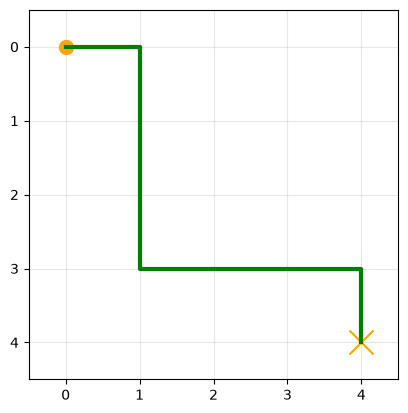

In [ ]:
env.visualize_one_traj(all_trajs[0])

In [ ]:
# import numpy as np
# from itertools import combinations

# prefixes = all_trajs[:, :-1]                      # (1960, 18) coordinate part
# _, inverse, counts = np.unique(
#     prefixes, axis=0, return_inverse=True, return_counts=True
# )
# inverse = inverse.ravel()                          # guard against numpy 2.0 shape quirk

# # row indices grouped by identical prefix, keeping only groups with >1 member
# groups = [np.where(inverse == g)[0] for g in np.where(counts > 1)[0]]
# pairs = [p for g in groups for p in combinations(g, 2)]

In [21]:
import numpy as np
tilted_traj = np.array([ 0., 0., 1., 0., 1., 1., 1., 2., 1., 3.,
                    2., 3., 3., 3., 4., 3., 4., 4., 1.5708])
upright_traj = np.array([ 0., 0., 1., 0., 1., 1., 1., 2., 1., 3.,
                    2., 3., 3., 3., 4., 3., 4., 4., 0])

tilted_idx= np.where((all_trajs == tilted_traj).all(axis=1))[0][0]
upright_idx = np.where((all_trajs == upright_traj).all(axis=1))[0][0]

1608 feature_values
tensor([[-0.4240,  0.2667, -0.7041,  0.1072]], grad_fn=<MmBackward0>)
{1, 3}
1150 feature_values
tensor([[-0.2408,  0.3264, -0.5865,  0.1583]], grad_fn=<MmBackward0>)
{1, 3}
Expression evaluated to empty feature set.


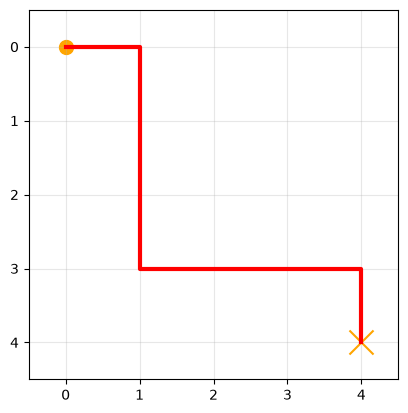

minus...


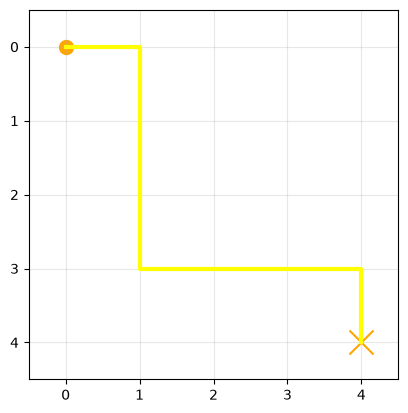

equals...
------
1150 feature_values
tensor([[-0.2408,  0.3264, -0.5865,  0.1583]], grad_fn=<MmBackward0>)
{1, 3}
1608 feature_values
tensor([[-0.4240,  0.2667, -0.7041,  0.1072]], grad_fn=<MmBackward0>)
{1, 3}
Expression evaluated to empty feature set.


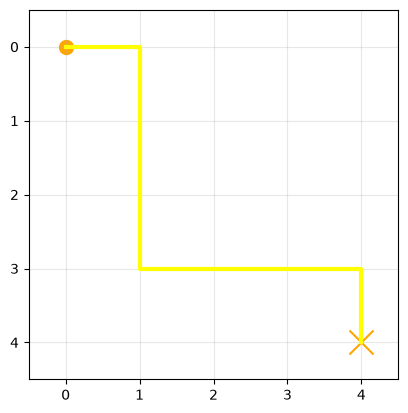

minus...


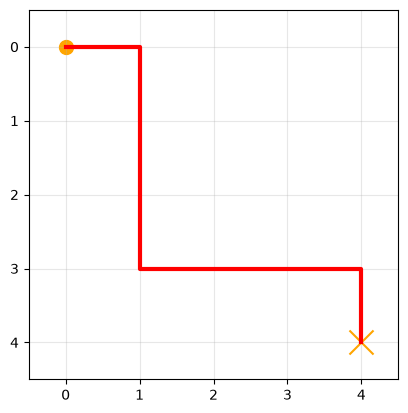

equals...


In [23]:
res = retrieve_semantic_expression(
    instance_vectors=centered_embeds, #(N, D)
    feature_bank=feature_bank, # (F, D)
    expression=f"s({tilted_idx})-s({upright_idx})", 
    top_feature_count=4,
    top_result_count=5,
)

env.visualize_one_traj(tilted_traj)
print("minus...")
env.visualize_one_traj(upright_traj)
print("equals...")
for instance in res["top_instances"]:
    idx = instance["item_ix"]
    env.visualize_one_traj(all_trajs[idx])

print("------")

res = retrieve_semantic_expression(
    instance_vectors=centered_embeds, #(N, D)
    feature_bank=feature_bank, # (F, D)
    expression=f"s({upright_idx})-s({tilted_idx})", 
    top_feature_count=4,
    top_result_count=5,
)

env.visualize_one_traj(upright_traj)
print("minus...")
env.visualize_one_traj(tilted_traj)
print("equals...")
for instance in res["top_instances"]:
    idx = instance["item_ix"]
    env.visualize_one_traj(all_trajs[idx])